In [51]:
import pandas as pd
import numpy as np

In [52]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [53]:
import matplotlib.pyplot as plt

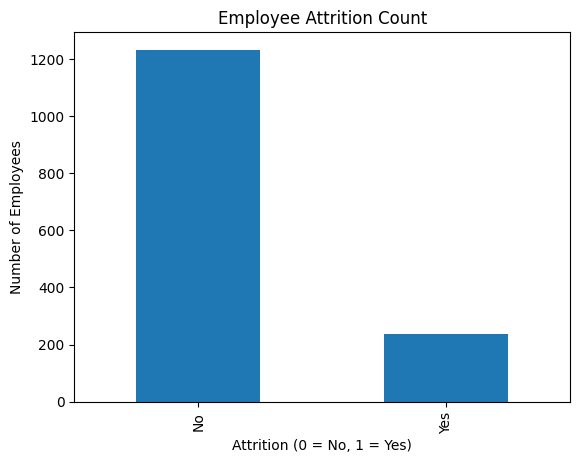

In [54]:
df["Attrition"].value_counts().plot(kind='bar')

plt.title("Employee Attrition Count")
plt.xlabel("Attrition (0 = No, 1 = Yes)")
plt.ylabel("Number of Employees")
plt.show()

In [55]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["Attrition"]

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [57]:
correlation = df.corr(numeric_only=True)

In [58]:
attrition_corr = correlation["Attrition"].sort_values(ascending=False)

print(attrition_corr)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
N

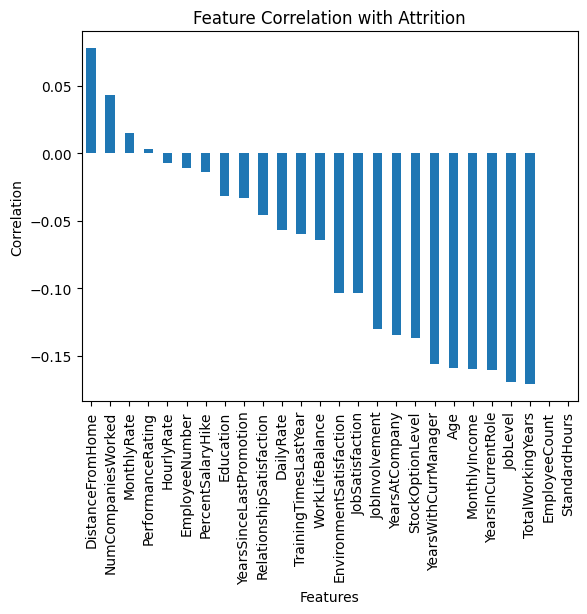

In [59]:
import matplotlib.pyplot as plt

# Remove self-correlation
attrition_corr = attrition_corr.drop("Attrition")

attrition_corr.plot(kind='bar')

plt.title("Feature Correlation with Attrition")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=90)
plt.show()

In [48]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,NaN,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,NaN,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,NaN,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,NaN,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,NaN,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [9]:
df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"],
        axis=1, inplace=True, errors='ignore')

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [12]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])
    

C:\Users\Hema\AppData\Local\Temp\ipykernel_15324\326308198.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [13]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8741496598639455

Confusion Matrix:
 [[239   8]
 [ 29  18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



In [22]:
import joblib

In [23]:
joblib.dump(model, "attrition_model.pkl")
joblib.dump(scaler, "attrition_scaler.pkl")

print("\nModel and scaler saved!")


Model and scaler saved!


In [24]:
import joblib
import numpy as np


In [25]:
model = joblib.load("attrition_model.pkl")
scaler = joblib.load("attrition_scaler.pkl")


In [67]:
sample = np.array([[35, 2, 3, 1, 1000, 2, 3, 1, 2, 10, 3, 2, 1, 3, 2, 1, 3, 2, 4, 3,3,4,5,6,1,2,3,4,5,2]])
sample


array([[  35,    2,    3,    1, 1000,    2,    3,    1,    2,   10,    3,
           2,    1,    3,    2,    1,    3,    2,    4,    3,    3,    4,
           5,    6,    1,    2,    3,    4,    5,    2]])

In [68]:
print(scaler.n_features_in_)

30


In [69]:
sample = scaler.transform(sample)
sample

C:\Users\Hema\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-2.10660704e-01,  5.90048338e-01, -1.98200682e+00,
        -4.93817137e-01,  1.22259928e+02, -8.91688250e-01,
         5.65310548e-01, -1.57568627e+00,  2.85773803e+00,
        -2.75020910e+00,  3.79672129e-01, -5.77875453e-02,
        -1.40533367e+00,  2.46200205e-01,  1.23682046e+00,
        -1.38152159e+00, -2.01115532e+00, -2.77594348e-01,
         8.25170550e+00, -3.33712751e+00, -4.26230015e-01,
         1.19143799e+00,  4.93799912e+00, -6.78773516e-01,
        -1.39608553e+00, -1.07786213e+00, -6.54453737e-01,
        -6.32958994e-02,  8.73006299e-01, -5.95227228e-01]])

In [70]:
prediction = model.predict(sample)
prediction

array([1])

In [71]:
 import matplotlib.pyplot as plt

In [72]:
if prediction[0] == 1:
    print("⚠️ Employee likely to leave")
else:
    print("✅ Employee likely to stay")

⚠️ Employee likely to leave


In [73]:
if prediction[0] == 1:
    label = ["Leave"]
    value = [1]
else:
    label = ["Stay"]
    value = [1]


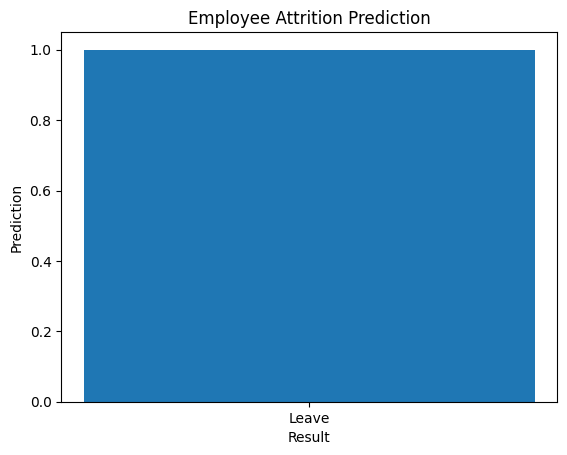

In [74]:
plt.bar(label, value)

plt.title("Employee Attrition Prediction")
plt.xlabel("Result")
plt.ylabel("Prediction")

plt.show()